<a href="https://colab.research.google.com/github/Gnissan-BIA/Assignments/blob/main/Assignment_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

#Load Dataset

In [3]:
dataset = fetch_ucirepo(id=350)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

# Combine into one dataframe
df = pd.concat([X, y], axis=1)

# Rename target for easier use
target_col = df.columns[-1]
df = df.rename(columns={target_col: "default"})

print("Shape:", df.shape)
print(df.head())

Shape: (30000, 24)
       X1  X2  X3  X4  X5  X6  X7  X8  X9  X10  ...    X15    X16    X17  \
0   20000   2   2   1  24   2   2  -1  -1   -2  ...      0      0      0   
1  120000   2   2   2  26  -1   2   0   0    0  ...   3272   3455   3261   
2   90000   2   2   2  34   0   0   0   0    0  ...  14331  14948  15549   
3   50000   2   2   1  37   0   0   0   0    0  ...  28314  28959  29547   
4   50000   1   2   1  57  -1   0  -1   0    0  ...  20940  19146  19131   

    X18    X19    X20   X21   X22   X23  default  
0     0    689      0     0     0     0        1  
1     0   1000   1000  1000     0  2000        1  
2  1518   1500   1000  1000  1000  5000        0  
3  2000   2019   1200  1100  1069  1000        0  
4  2000  36681  10000  9000   689   679        0  

[5 rows x 24 columns]


#Data Preparation

Basic cleaning

In [4]:
# Remove ID if present
if "ID" in df.columns:
    df.drop(columns=["ID"], inplace=True)

# Standardize column names
df.columns = [col.strip().upper() for col in df.columns]

# Rename target again after upper-case conversion
if "DEFAULT" in df.columns:
    pass
elif "DEFAULT PAYMENT NEXT MONTH" in df.columns:
    df = df.rename(columns={"DEFAULT PAYMENT NEXT MONTH": "DEFAULT"})

# Rename generic X columns to descriptive names based on common UCI Credit Card Default dataset interpretation
rename_map = {
    "X1": "LIMIT_BAL",
    "X2": "SEX",
    "X3": "EDUCATION",
    "X4": "MARRIAGE",
    "X5": "AGE",
    "X6": "PAY_0",
    "X7": "PAY_2",
    "X8": "PAY_3",
    "X9": "PAY_4",
    "X10": "PAY_5",
    "X11": "PAY_6",
    "X12": "BILL_AMT1",
    "X13": "BILL_AMT2",
    "X14": "BILL_AMT3",
    "X15": "BILL_AMT4",
    "X16": "BILL_AMT5",
    "X17": "BILL_AMT6",
    "X18": "PAY_AMT1",
    "X19": "PAY_AMT2",
    "X20": "PAY_AMT3",
    "X21": "PAY_AMT4",
    "X22": "PAY_AMT5",
    "X23": "PAY_AMT6"
}
df = df.rename(columns=rename_map)

print(df.head())

   LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0      20000    2          2         1   24      2      2     -1     -1   
1     120000    2          2         2   26     -1      2      0      0   
2      90000    2          2         2   34      0      0      0      0   
3      50000    2          2         1   37      0      0      0      0   
4      50000    1          2         1   57     -1      0     -1      0   

   PAY_5  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0     -2  ...          0          0          0         0       689         0   
1      0  ...       3272       3455       3261         0      1000      1000   
2      0  ...      14331      14948      15549      1518      1500      1000   
3      0  ...      28314      28959      29547      2000      2019      1200   
4      0  ...      20940      19146      19131      2000     36681     10000   

   PAY_AMT4  PAY_AMT5  PAY_AMT6  DEFAULT  
0         0         0    

Check missing values

In [5]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
DEFAULT      0
dtype: int64


Fix categories

In [6]:
if "EDUCATION" in df.columns:
    df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})

if "MARRIAGE" in df.columns:
    df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})


#EDA

Summary Statistics

In [7]:
print("\nSummary statistics:\n")
print(df.describe(include="all"))

print("\nClass distribution:\n")
print(df["DEFAULT"].value_counts(normalize=True))



Summary statistics:

            LIMIT_BAL           SEX     EDUCATION      MARRIAGE           AGE  \
count    30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean    167484.322667      1.603733      1.842267      1.557267     35.485500   
std     129747.661567      0.489129      0.744494      0.521405      9.217904   
min      10000.000000      1.000000      1.000000      1.000000     21.000000   
25%      50000.000000      1.000000      1.000000      1.000000     28.000000   
50%     140000.000000      2.000000      2.000000      2.000000     34.000000   
75%     240000.000000      2.000000      2.000000      2.000000     41.000000   
max    1000000.000000      2.000000      4.000000      3.000000     79.000000   

              PAY_0         PAY_2         PAY_3         PAY_4         PAY_5  \
count  30000.000000  30000.000000  30000.000000  30000.000000  30000.000000   
mean      -0.016700     -0.133767     -0.166200     -0.220667     -0.266200   
std        

#Visualization

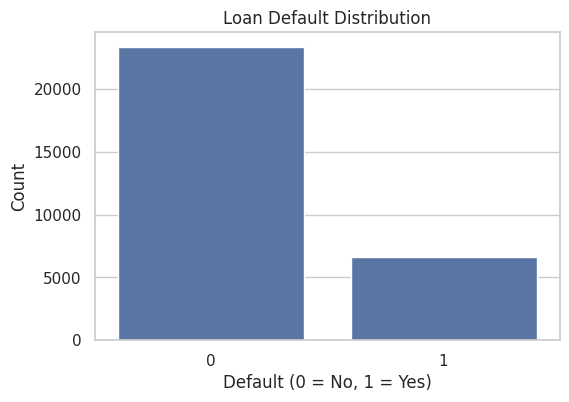

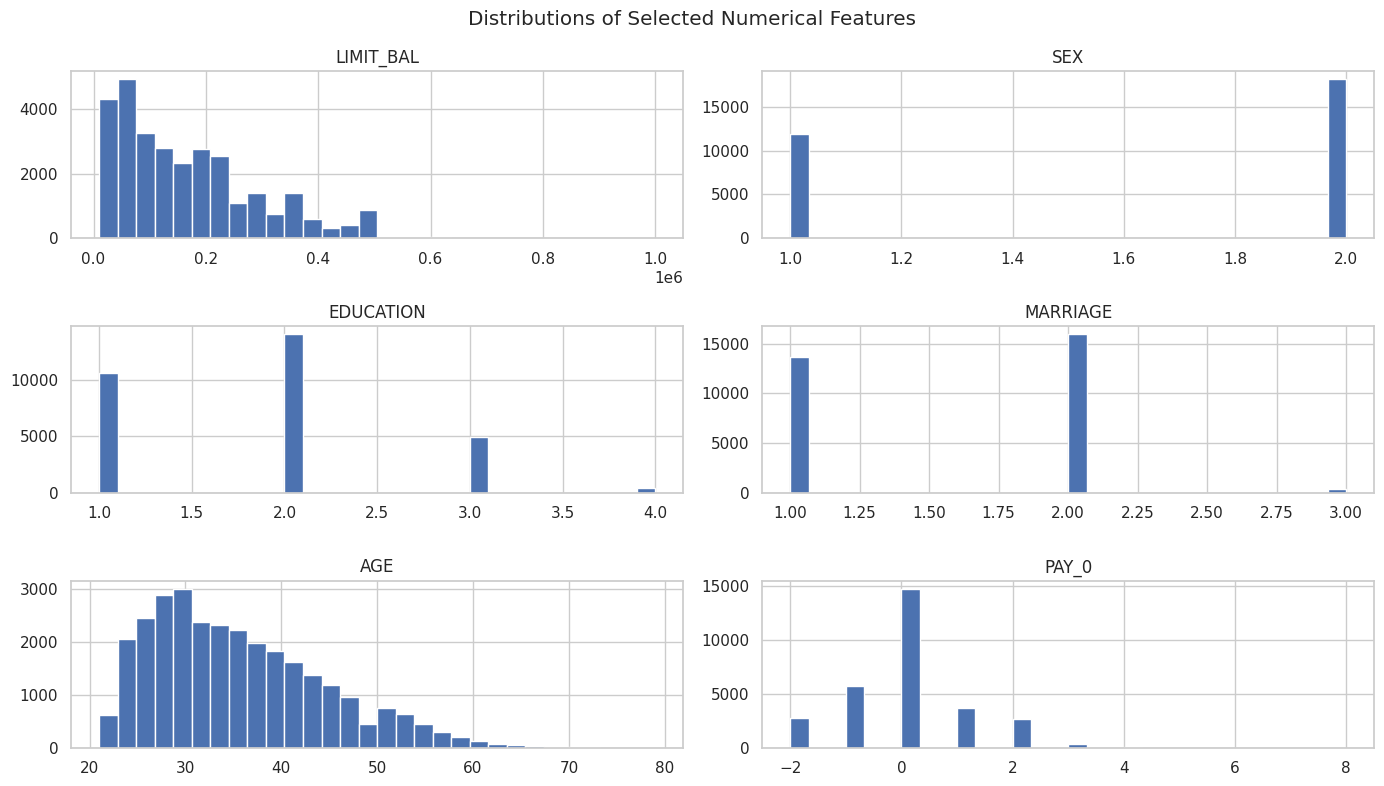

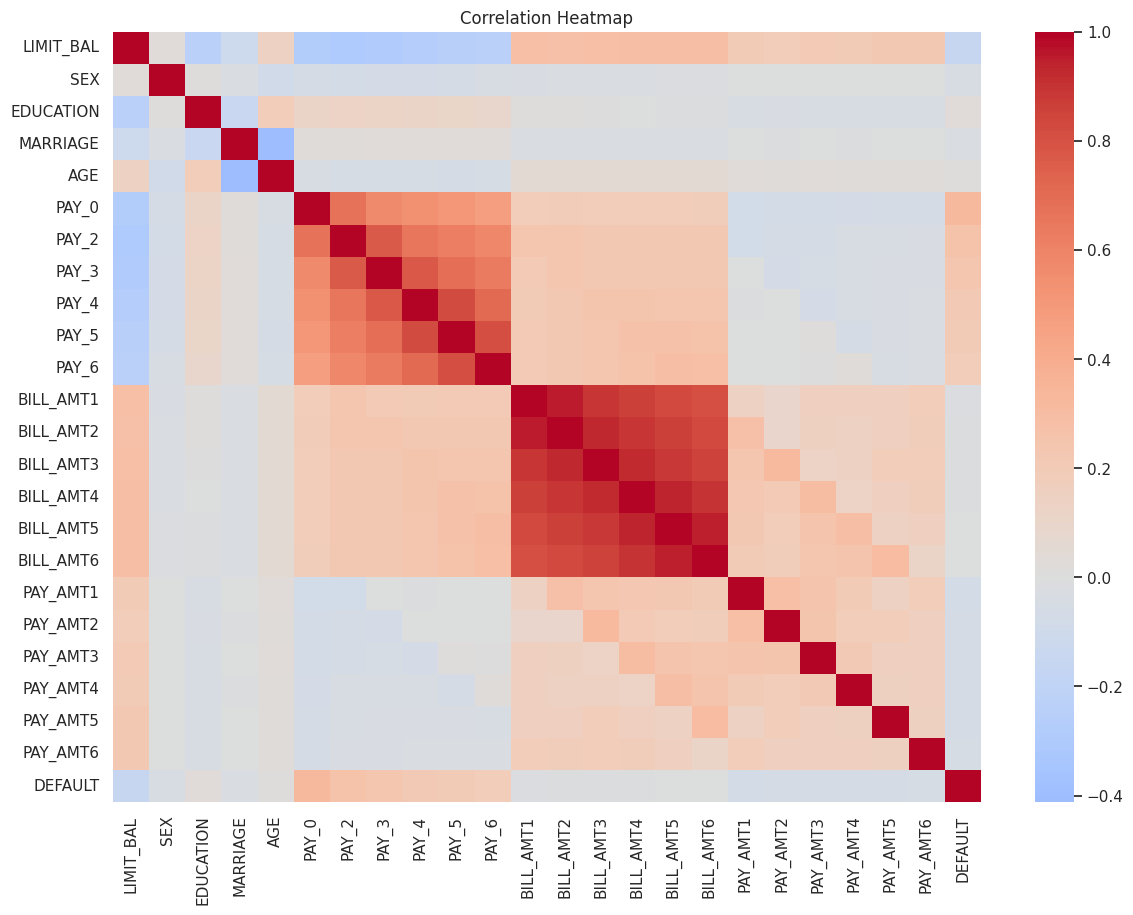

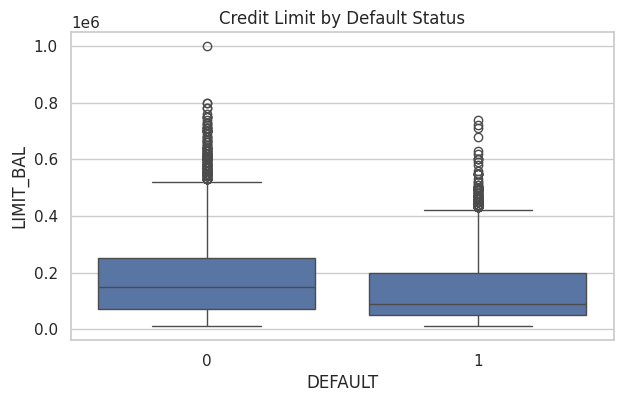

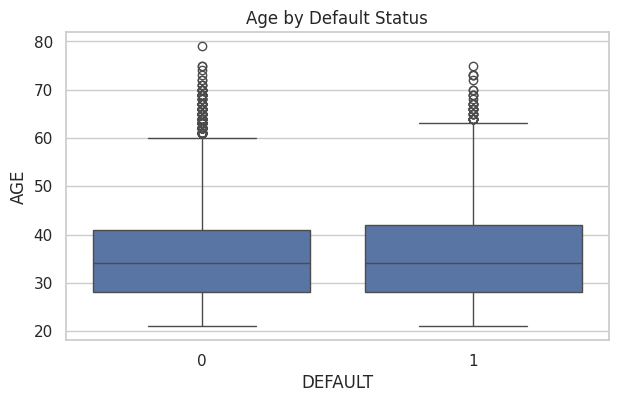

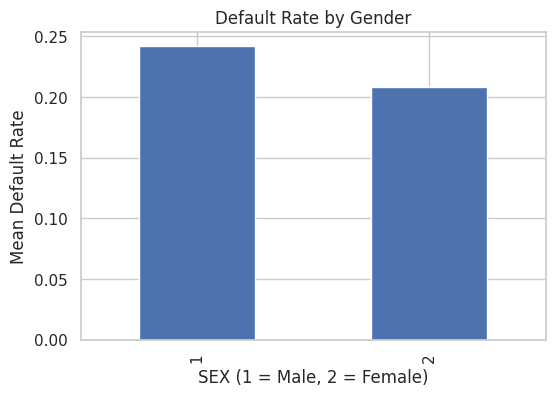

In [8]:
sns.set_theme(style="whitegrid")

# Target variable distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="DEFAULT")
plt.title("Loan Default Distribution")
plt.xlabel("Default (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

# Numeric distributions
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
numeric_cols_no_target = [c for c in numeric_cols if c != "DEFAULT"]

df[numeric_cols_no_target[:6]].hist(figsize=(14, 8), bins=30)
plt.suptitle("Distributions of Selected Numerical Features")
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

# Relationship with target
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="DEFAULT", y="LIMIT_BAL") # Fixed: Changed X1 to LIMIT_BAL
plt.title("Credit Limit by Default Status")
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x="DEFAULT", y="AGE") # Fixed: Changed X5 to AGE
plt.title("Age by Default Status")
plt.show()

# Default rate by gender
if "SEX" in df.columns: # Fixed: Changed X2 to SEX
    gender_default = df.groupby("SEX")["DEFAULT"].mean()
    fig, ax = plt.subplots(figsize=(6, 4)) # Explicitly create figure and axes
    gender_default.plot(kind="bar", ax=ax) # Plot on the created axes
    ax.set_title("Default Rate by Gender") # Use ax.set_title instead of plt.title
    ax.set_xlabel("SEX (1 = Male, 2 = Female)") # Use ax.set_xlabel
    ax.set_ylabel("Mean Default Rate") # Use ax.set_ylabel
    plt.show()

#TASK 2 Feature engineering and scaling

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

Feature engineering

In [10]:
df_fe = df.copy()

bill_cols = ["BILL_AMT1", "BILL_AMT2", "BILL_AMT3", "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"]
pay_amt_cols = ["PAY_AMT1", "PAY_AMT2", "PAY_AMT3", "PAY_AMT4", "PAY_AMT5", "PAY_AMT6"]
pay_status_cols = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]

# Average bill amount
df_fe["AVG_BILL_AMT"] = df_fe[bill_cols].mean(axis=1)

# Average payment amount
df_fe["AVG_PAY_AMT"] = df_fe[pay_amt_cols].mean(axis=1)

# Total bill and payment
df_fe["TOTAL_BILL_AMT"] = df_fe[bill_cols].sum(axis=1)
df_fe["TOTAL_PAY_AMT"] = df_fe[pay_amt_cols].sum(axis=1)

# Payment ratio
df_fe["PAYMENT_RATIO"] = df_fe["TOTAL_PAY_AMT"] / (df_fe["TOTAL_BILL_AMT"].abs() + 1)

# Max delay history
df_fe["MAX_DELAY"] = df_fe[pay_status_cols].max(axis=1)

# Average delay
df_fe["AVG_DELAY"] = df_fe[pay_status_cols].mean(axis=1)

# Utilization-like ratio
df_fe["BILL_TO_LIMIT_RATIO"] = df_fe["TOTAL_BILL_AMT"] / (df_fe["LIMIT_BAL"] + 1)

# Age groups (optional)
df_fe["AGE_GROUP"] = pd.cut(
    df_fe["AGE"],
    bins=[20, 30, 40, 50, 60, 80],
    labels=["21-30", "31-40", "41-50", "51-60", "61+"]
)


Encode categorical variables

In [11]:
categorical_cols = ["SEX", "EDUCATION", "MARRIAGE", "AGE_GROUP"]
categorical_cols = [c for c in categorical_cols if c in df_fe.columns]

df_model = pd.get_dummies(df_fe, columns=categorical_cols, drop_first=True)

Split X and Y

In [12]:
X = df_model.drop(columns=["DEFAULT"])
y = df_model["DEFAULT"]

# Save protected attribute before scaling for fairness later
protected_group = df_fe["SEX"].copy()

Train test split

In [13]:
X_train, X_test, y_train, y_test, group_train, group_test = train_test_split(
    X, y, protected_group,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
print(f"Type of X_train: {type(X_train)}")
print(f"Shape of X_train: {X_train.shape}")

print(f"Type of y_train: {type(y_train)}")
print(f"Shape of y_train: {y_train.shape}")

print(f"Type of group_train: {type(group_train)}")
print(f"Shape of group_train: {group_train.shape}")

Type of X_train: <class 'pandas.core.frame.DataFrame'>
Shape of X_train: (24000, 38)
Type of y_train: <class 'pandas.core.series.Series'>
Shape of y_train: (24000,)
Type of group_train: <class 'pandas.core.series.Series'>
Shape of group_train: (24000,)


Scale numerical features

In [15]:
numeric_cols = X_train.select_dtypes(include=np.number).columns.tolist()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Training set shape:", X_train_scaled.shape)
print("Test set shape:", X_test_scaled.shape)

Training set shape: (24000, 38)
Test set shape: (6000, 38)


#Task 3: Model building, evaluation, feature importance

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)


Train model

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=300, random_state=42)

Predictions

In [18]:
y_pred = rf_model.predict(X_test_scaled)


Evaluation

Accuracy: 0.7813333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.84      0.86      4673
           1       0.50      0.58      0.54      1327

    accuracy                           0.78      6000
   macro avg       0.69      0.71      0.70      6000
weighted avg       0.79      0.78      0.79      6000



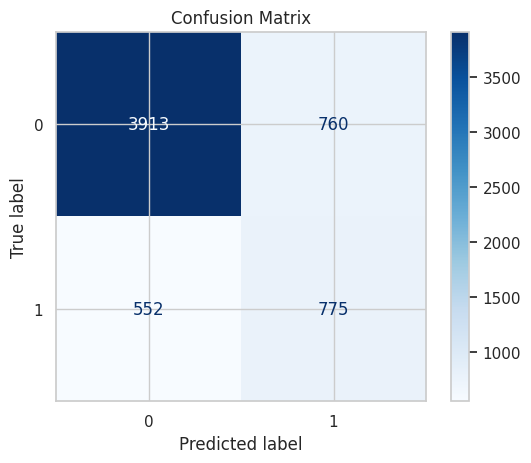

In [19]:
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", acc)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

Feature Importance

                Feature  Importance
2                 PAY_0    0.136464
25            MAX_DELAY    0.123933
26            AVG_DELAY    0.119002
3                 PAY_2    0.062197
27  BILL_TO_LIMIT_RATIO    0.033880
23        TOTAL_PAY_AMT    0.033834
21          AVG_PAY_AMT    0.032210
0             LIMIT_BAL    0.030462
24        PAYMENT_RATIO    0.028731
4                 PAY_3    0.027939
8             BILL_AMT1    0.024801
20         AVG_BILL_AMT    0.024516
15             PAY_AMT2    0.023365
14             PAY_AMT1    0.023315
22       TOTAL_BILL_AMT    0.022937


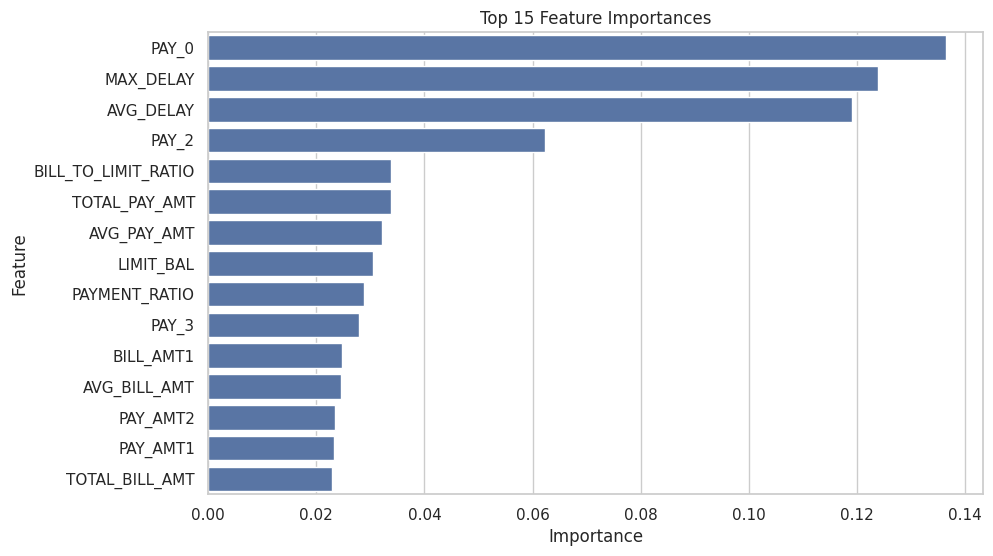

In [20]:
importances = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importances.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(data=importances.head(15), x="Importance", y="Feature")
plt.title("Top 15 Feature Importances")
plt.show()

#Task 4: SHAP explainability and fairness analysis

SHAQ and Fairness

In [21]:
import shap
from sklearn.metrics import precision_score, recall_score, f1_score

SHAQ explainability

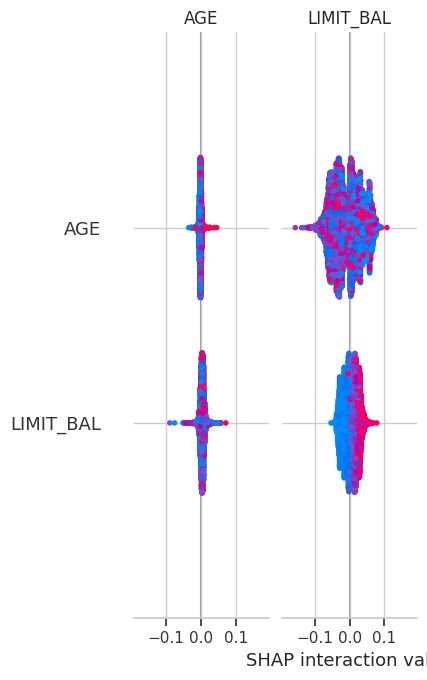

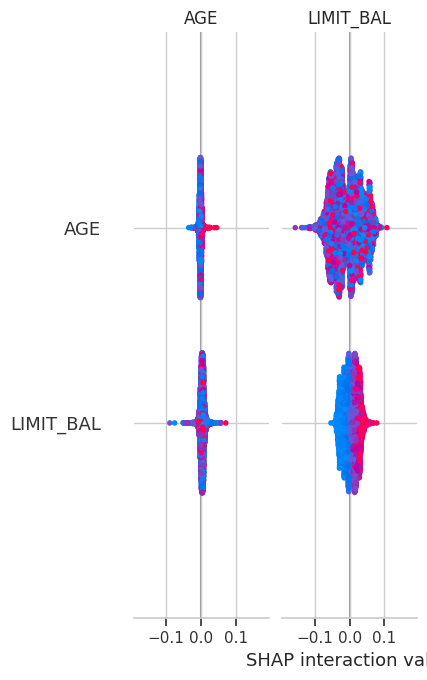

In [22]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_scaled)

# For binary classification

if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]
else:
    shap_values_to_plot = shap_values

# Summary plot
shap.summary_plot(shap_values_to_plot, X_test_scaled, plot_type="bar")
shap.summary_plot(shap_values_to_plot, X_test_scaled)




Fairness Analysis by Gender


Fairness Metrics by Gender:

     accuracy  precision    recall  f1_score  default_rate_predicted  \
SEX                                                                    
1    0.764363   0.496218  0.584670  0.536825                0.275187   
2    0.792663   0.511442  0.583551  0.545122                0.242913   

     default_rate_actual  
SEX                       
1               0.233555  
2               0.212896  


/tmp/ipykernel_11712/510840593.py:17: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fairness_table = results.groupby("SEX").apply(group_metrics)


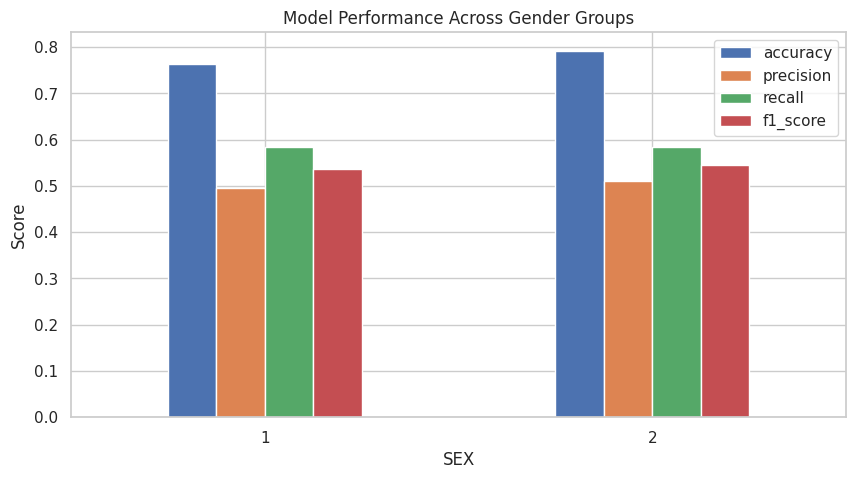


Demographic Parity Difference: 0.03227461458604766
Equal Opportunity Difference (Recall gap): 0.001119317890935223


In [23]:
results = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": y_pred,
    "SEX": group_test.values
})

def group_metrics(df_group):
    return pd.Series({
        "accuracy": accuracy_score(df_group["y_true"], df_group["y_pred"]),
        "precision": precision_score(df_group["y_true"], df_group["y_pred"], zero_division=0),
        "recall": recall_score(df_group["y_true"], df_group["y_pred"], zero_division=0),
        "f1_score": f1_score(df_group["y_true"], df_group["y_pred"], zero_division=0),
        "default_rate_predicted": df_group["y_pred"].mean(),
        "default_rate_actual": df_group["y_true"].mean()
    })

fairness_table = results.groupby("SEX").apply(group_metrics)
print("\nFairness Metrics by Gender:\n")
print(fairness_table)

# Visualize fairness comparison
fairness_table[["accuracy", "precision", "recall", "f1_score"]].plot(kind="bar", figsize=(10, 5))
plt.title("Model Performance Across Gender Groups")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

# Demographic parity difference
dp_diff = abs(
    fairness_table.loc[1, "default_rate_predicted"] - fairness_table.loc[2, "default_rate_predicted"]
)
print("\nDemographic Parity Difference:", dp_diff)

# Equal opportunity difference /difference in recall
eo_diff = abs(
    fairness_table.loc[1, "recall"] - fairness_table.loc[2, "recall"]
)
print("Equal Opportunity Difference (Recall gap):", eo_diff)